# Retrieval-Augmented Classification — Stratified Analysis
## 9-Partition Label | FST-Resampled | Light / Medium / Dark

**Tone groups follow Fitzpatrick17k original grouping:**
- Light   = FST I–II
- Medium  = FST III–IV
- Dark    = FST V–VI

**Tone-aware kNN is isolated to Section 8 (RQ2). All other sections use standard kNN.**

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import normalize
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')


Imports OK


In [4]:
# ── CONFIG ─────────────────────────────────────────────────────────────────────
EMBEDDINGS_PATH = '/content/drive/MyDrive/277Project/df_dermaamin_with_embeddings.npy'
METADATA_PATH   = '/content/drive/MyDrive/277Project/df_dermaamin_with_embeddings.csv'

K            = 10
N_SPLITS     = 5
TONE_BOOST   = 1.25   # only used in Section 8 (tone-aware ablation)
RANDOM_STATE = 42

FITZ_COL      = 'fitzpatrick_scale'

# Three-tier grouping — matches original Fitzpatrick17k reporting
LIGHT_GROUP  = 'Light (I-II)'
MEDIUM_GROUP = 'Medium (III-IV)'
DARK_GROUP   = 'Dark (V-VI)'

def fst_to_tone(fst):
    if fst in [1, 2]:   return LIGHT_GROUP
    if fst in [3, 4]:   return MEDIUM_GROUP
    if fst in [5, 6]:   return DARK_GROUP
    return None

TONE_GROUPS  = [LIGHT_GROUP, MEDIUM_GROUP, DARK_GROUP]
TONE_COLORS  = {LIGHT_GROUP: '#4C72B0', MEDIUM_GROUP: '#55A868', DARK_GROUP: '#C44E52'}


## 1. Load Data

In [5]:
def load_data(emb_path, meta_path):
    embeddings = np.load(emb_path)
    df = pd.read_csv(meta_path)
    # Assign three-tier tone group
    df['tone_group'] = df[FITZ_COL].map(fst_to_tone)
    df = df[df['tone_group'].notna()].reset_index(drop=True)
    embeddings = normalize(embeddings[df['embedding_idx'].values], norm='l2')
    return embeddings, df.reset_index(drop=True)

embeddings, df = load_data(EMBEDDINGS_PATH, METADATA_PATH)
print(f'Embeddings : {embeddings.shape}')
print(f'Samples    : {len(df)}')
print()
print(df[FITZ_COL].value_counts().sort_index().rename('count').to_frame())
print()
print(df['tone_group'].value_counts().rename('count').to_frame())


Embeddings : (12222, 512)
Samples    : 12222

                   count
fitzpatrick_scale       
1                   2780
2                   4137
3                   2298
4                   1689
5                    891
6                    427

                 count
tone_group            
Light (I-II)      6917
Medium (III-IV)   3987
Dark (V-VI)       1318


In [6]:
# Resample to match full Fitzpatrick17k FST distribution
FULL_DIST  = {1: 3200, 2: 5200, 3: 2600, 4: 1800, 5: 1500, 6: 1100}
FULL_TOTAL = sum(FULL_DIST.values())
FULL_PROPS = {k: v / FULL_TOTAL for k, v in FULL_DIST.items()}

subset_counts = df[df[FITZ_COL] > 0][FITZ_COL].value_counts().to_dict()
max_total     = int(min(subset_counts[t] / FULL_PROPS[t]
                        for t in FULL_PROPS if t in subset_counts))
target_counts = {t: int(FULL_PROPS[t] * max_total) for t in FULL_PROPS}

print(f"{'Type':<8} {'Available':>10} {'Target':>8} {'Full %':>8}")
for t in sorted(target_counts):
    print(f"  FST {t}   {subset_counts.get(t,0):>10}   {target_counts[t]:>7}   {FULL_PROPS[t]*100:>6.1f}%")
print(f"\nTotal resampled: {sum(target_counts.values())}")


Type      Available   Target   Full %
  FST 1         2780      1242     20.8%
  FST 2         4137      2018     33.8%
  FST 3         2298      1009     16.9%
  FST 4         1689       698     11.7%
  FST 5          891       582      9.7%
  FST 6          427       427      7.1%

Total resampled: 5976


In [7]:
import random
random.seed(RANDOM_STATE)

resampled_idx = []
for t, n in target_counts.items():
    pool    = df[df[FITZ_COL] == t].index.tolist()
    sampled = random.sample(pool, n)
    resampled_idx.extend(sampled)

resampled_idx = sorted(resampled_idx)
df_resampled  = df.loc[resampled_idx].reset_index(drop=True)
emb_resampled = embeddings[resampled_idx]

print('Resampled distribution:')
for t in sorted(target_counts):
    n = (df_resampled[FITZ_COL] == t).sum()
    print(f'  FST {t}: n={n:4d}  ({n/len(df_resampled)*100:.1f}%)')

print()
for grp in TONE_GROUPS:
    n = (df_resampled['tone_group'] == grp).sum()
    print(f'  {grp}: {n} ({n/len(df_resampled)*100:.1f}%)')


Resampled distribution:
  FST 1: n=1242  (20.8%)
  FST 2: n=2018  (33.8%)
  FST 3: n=1009  (16.9%)
  FST 4: n= 698  (11.7%)
  FST 5: n= 582  (9.7%)
  FST 6: n= 427  (7.1%)

  Light (I-II): 3260 (54.6%)
  Medium (III-IV): 1707 (28.6%)
  Dark (V-VI): 1009 (16.9%)


## 2. kNN Core Functions

In [8]:
def weighted_vote(neighbor_labels, neighbor_sims):
    scores = defaultdict(float)
    for lbl, sim in zip(neighbor_labels, neighbor_sims):
        scores[lbl] += float(sim)
    return max(scores, key=scores.get)


def knn_predict(query_embs, train_embs, train_labels, k=K):
    """Standard kNN with similarity-weighted voting."""
    sim   = query_embs @ train_embs.T
    preds = []
    for i in range(len(query_embs)):
        top_k = np.argsort(sim[i])[::-1][:k]
        preds.append(weighted_vote(train_labels[top_k], sim[i][top_k]))
    return np.array(preds)


def tone_aware_knn_predict(query_embs, query_tones,
                           train_embs, train_labels, train_tones,
                           k=K, boost=TONE_BOOST):
    """
    Tone-aware kNN (RQ2 only):
    For Dark (V-VI) queries, boost same-tone neighbor similarities before
    selecting top-k; vote with original similarities.
    All other queries use standard retrieval.
    """
    sim   = query_embs @ train_embs.T
    preds = []
    for i in range(len(query_embs)):
        raw = sim[i].copy()
        if query_tones[i] == DARK_GROUP:
            boosted = raw.copy()
            boosted[train_tones == DARK_GROUP] *= boost
            top_k = np.argsort(boosted)[::-1][:k]
            preds.append(weighted_vote(train_labels[top_k], raw[top_k]))
        else:
            top_k = np.argsort(raw)[::-1][:k]
            preds.append(weighted_vote(train_labels[top_k], raw[top_k]))
    return np.array(preds)

print('Core functions defined.')


Core functions defined.


## 3. Cross-Validation (Standard kNN)

In [9]:
def run_cv_collect(embeddings, df, label_col='nine_partition_label', k=K):
    """Run stratified k-fold CV — standard kNN only."""
    labels = df[label_col].values
    tones  = df['tone_group'].values

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    out_idx, std_preds_all = [], []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(embeddings, labels)):
        tr_embs, tr_labels = embeddings[tr_idx], labels[tr_idx]
        te_embs, te_labels = embeddings[te_idx], labels[te_idx]

        std_preds = knn_predict(te_embs, tr_embs, tr_labels, k=k)
        out_idx.extend(te_idx)
        std_preds_all.extend(std_preds)

        print(f'  Fold {fold+1}/{N_SPLITS}  acc={accuracy_score(te_labels, std_preds):.3f}')

    order = np.argsort(out_idx)
    out_df = df.copy()
    out_df['true_label']       = labels
    out_df['pred_standard']    = np.array(std_preds_all)[order]
    out_df['correct_standard'] = (out_df['true_label'] == out_df['pred_standard']).astype(int)
    return out_df


print(f'Running CV — 9-partition, FST-resampled, standard kNN, k={K}...')
pred_df = run_cv_collect(emb_resampled, df_resampled, label_col='nine_partition_label', k=K)
overall = pred_df['correct_standard'].mean()
print(f'\nOverall accuracy: {overall:.3f}')


Running CV — 9-partition, FST-resampled, standard kNN, k=10...
  Fold 1/5  acc=0.695
  Fold 2/5  acc=0.711
  Fold 3/5  acc=0.717
  Fold 4/5  acc=0.710
  Fold 5/5  acc=0.707

Overall accuracy: 0.708


## 4. Per-Fitzpatrick Scale Accuracy

In [10]:
fitz_df = pred_df[pred_df[FITZ_COL] > 0]

fitz_table = (
    fitz_df.groupby(FITZ_COL)
    .agg(n=(FITZ_COL, 'count'), accuracy=('correct_standard', 'mean'))
    .round(3)
)
fitz_table.index = [f'Type {i}' for i in fitz_table.index]

group_table = (
    pred_df.groupby('tone_group')
    .agg(n=('tone_group', 'count'), accuracy=('correct_standard', 'mean'))
    .round(3)
    .reindex(TONE_GROUPS)
)

print('=== Per Fitzpatrick Type ===')
display(fitz_table)
print('\n=== Grouped (Light / Medium / Dark) ===')
display(group_table)


=== Per Fitzpatrick Type ===


,n,accuracy
Type 1,1242,0.707
Type 2,2018,0.701
Type 3,1009,0.713
Type 4,698,0.706
Type 5,582,0.710
Type 6,427,0.738



=== Grouped (Light / Medium / Dark) ===


,n,accuracy
tone_group,,
Light (I-II),3260,0.703
Medium (III-IV),1707,0.710
Dark (V-VI),1009,0.722


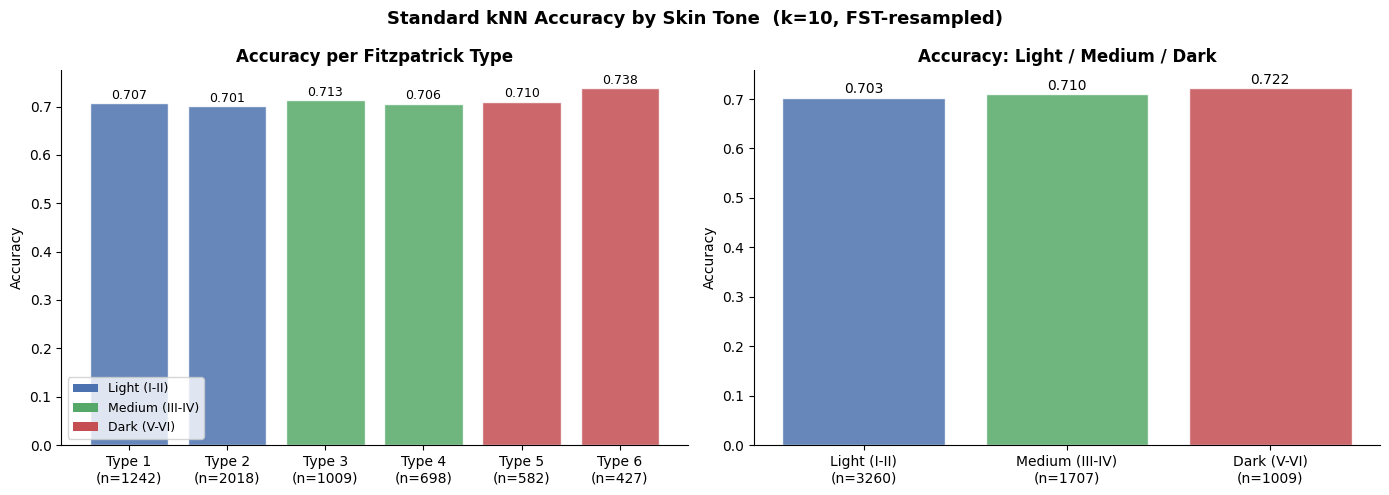

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per FST type
ax = axes[0]
x = np.arange(len(fitz_table))
colors = []
for t in [1,2,3,4,5,6]:
    grp = fst_to_tone(t)
    colors.append(TONE_COLORS[grp])
bars = ax.bar(x, fitz_table['accuracy'], color=colors, alpha=0.85, edgecolor='white')
for bar, (_, row) in zip(bars, fitz_table.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{row.accuracy:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([f'{t}\n(n={fitz_table["n"].iloc[j]})'
                    for j, t in enumerate(fitz_table.index)])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy per Fitzpatrick Type', fontweight='bold')
# Legend for tone groups
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=TONE_COLORS[g], label=g) for g in TONE_GROUPS]
ax.legend(handles=legend_elements, fontsize=9)
sns.despine(ax=ax)

# Right: grouped Light / Medium / Dark
ax = axes[1]
xg = np.arange(len(TONE_GROUPS))
bar_colors = [TONE_COLORS[g] for g in TONE_GROUPS]
bars = ax.bar(xg, group_table['accuracy'], color=bar_colors, alpha=0.85, edgecolor='white')
for bar, (_, row) in zip(bars, group_table.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{row.accuracy:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(xg)
ax.set_xticklabels([f'{g}\n(n={group_table["n"].iloc[j]})'
                    for j, g in enumerate(TONE_GROUPS)])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy: Light / Medium / Dark', fontweight='bold')
sns.despine(ax=ax)

plt.suptitle(f'Standard kNN Accuracy by Skin Tone  (k={K}, FST-resampled)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/fitz_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


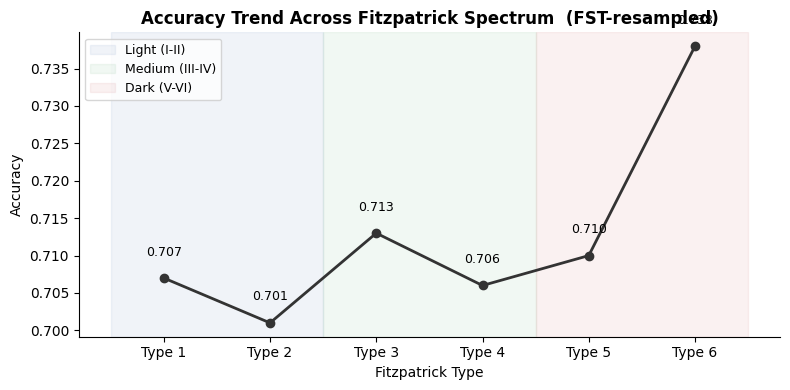

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
types = fitz_table.index.tolist()
ax.plot(types, fitz_table['accuracy'], marker='o', color='#333333', linewidth=2)
ax.axvspan(-0.5, 1.5,  alpha=0.08, color=TONE_COLORS[LIGHT_GROUP],  label=LIGHT_GROUP)
ax.axvspan(1.5,  3.5,  alpha=0.08, color=TONE_COLORS[MEDIUM_GROUP], label=MEDIUM_GROUP)
ax.axvspan(3.5,  5.5,  alpha=0.08, color=TONE_COLORS[DARK_GROUP],   label=DARK_GROUP)
for i, (t, row) in enumerate(fitz_table.iterrows()):
    ax.text(i, row.accuracy + 0.003, f'{row.accuracy:.3f}', ha='center', fontsize=9)
ax.set_ylabel('Accuracy')
ax.set_xlabel('Fitzpatrick Type')
ax.set_title('Accuracy Trend Across Fitzpatrick Spectrum  (FST-resampled)', fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('/content/fitz_trend.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Per-9-Partition Class Accuracy

In [13]:
label_col = 'nine_partition_label'

part_table = (
    pred_df.groupby(label_col)
    .agg(
        n        = (label_col,          'count'),
        accuracy = ('correct_standard', 'mean'),
        pct_dark = ('tone_group', lambda x: (x == DARK_GROUP).mean()),
    )
    .round(3)
    .sort_values('accuracy', ascending=False)
)
display(part_table)


,n,accuracy,pct_dark
nine_partition_label,,,
inflammatory,4011,0.960,0.175
malignant melanoma,229,0.424,0.092
malignant epidermal,386,0.394,0.083
genodermatoses,385,0.135,0.268
benign dermal,419,0.095,0.115
benign epidermal,359,0.089,0.162
benign melanocyte,88,0.057,0.170
malignant dermal,55,0.055,0.418
malignant cutaneous lymphoma,44,0.000,0.159


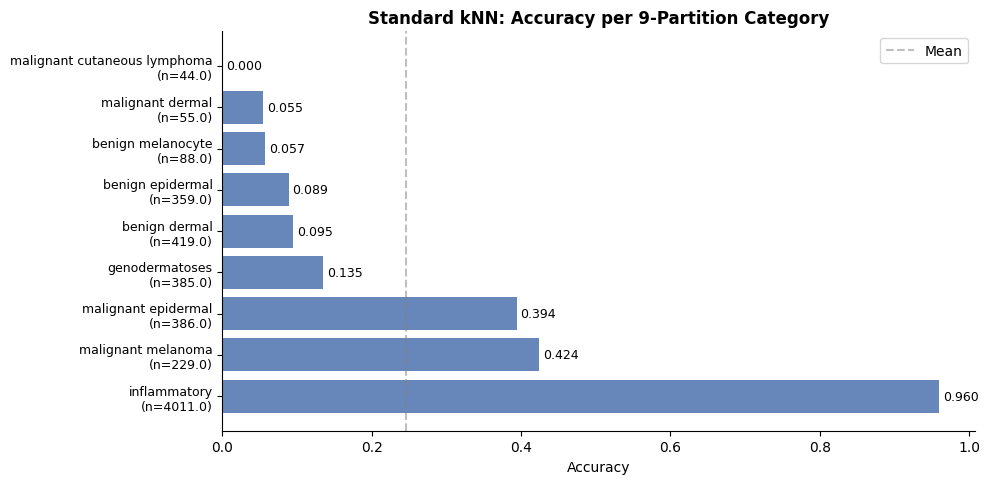

In [14]:
label_col = 'nine_partition_label'

part_table = (
    pred_df.groupby(label_col)
    .agg(n=(label_col,'count'), accuracy=('correct_standard','mean'))
    .sort_values('accuracy', ascending=False)
    .round(3)
)

fig, ax = plt.subplots(figsize=(10, max(4, len(part_table) * 0.55)))
y = np.arange(len(part_table))
bars = ax.barh(y, part_table['accuracy'], color='#4C72B0', alpha=0.85)
for bar, (_, row) in zip(bars, part_table.iterrows()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{row.accuracy:.3f}', va='center', fontsize=9)
ax.axvline(part_table['accuracy'].mean(), color='gray', linestyle='--', alpha=0.5, label='Mean')
ax.set_yticks(y)
ax.set_yticklabels([f'{lbl}\n(n={row.n})' for lbl, row in part_table.iterrows()], fontsize=9)
ax.set_xlabel('Accuracy')
ax.set_title('Standard kNN: Accuracy per 9-Partition Category', fontweight='bold')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('/content/barplot_nine_partition.png', dpi=150, bbox_inches='tight')
plt.show()


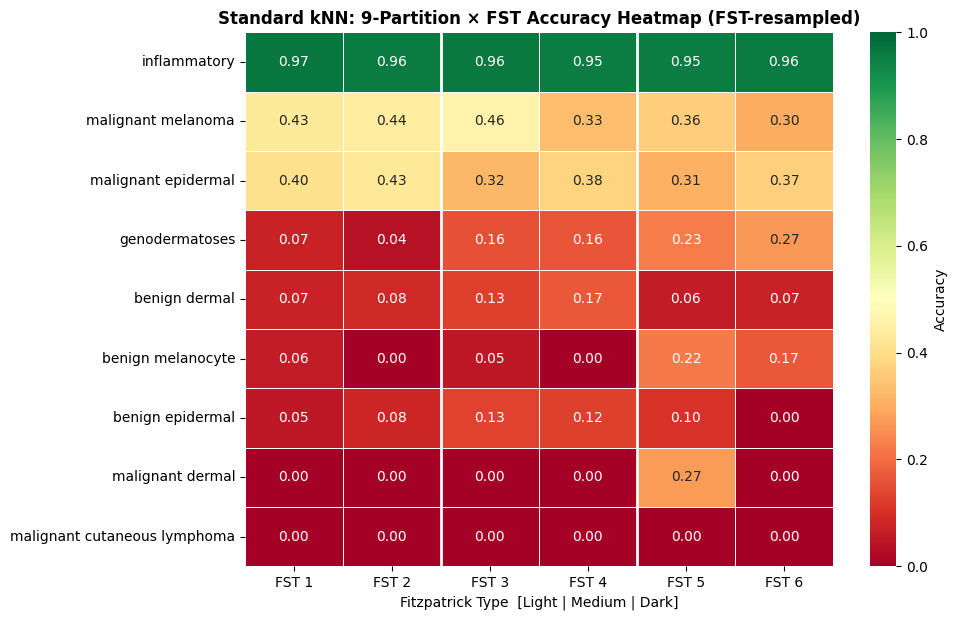

In [15]:
label_col = 'nine_partition_label'

pivot = (
    pred_df[pred_df[FITZ_COL] > 0]
    .groupby([label_col, FITZ_COL])['correct_standard']
    .mean()
    .unstack(FITZ_COL)
)
pivot.columns = [f'FST {c}' for c in pivot.columns]
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.7)))
sns.heatmap(pivot, ax=ax, cmap='RdYlGn', vmin=0, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 10},
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Accuracy'})
# Add column group labels
ax.axvline(2, color='white', linewidth=2)
ax.axvline(4, color='white', linewidth=2)
ax.set_xlabel('Fitzpatrick Type  [Light | Medium | Dark]')
ax.set_ylabel('')
ax.set_title('Standard kNN: 9-Partition × FST Accuracy Heatmap (FST-resampled)', fontweight='bold')
plt.tight_layout()
plt.savefig('/content/heatmap_nine_partition_fitz.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Accuracy by Tone Group and FST Type

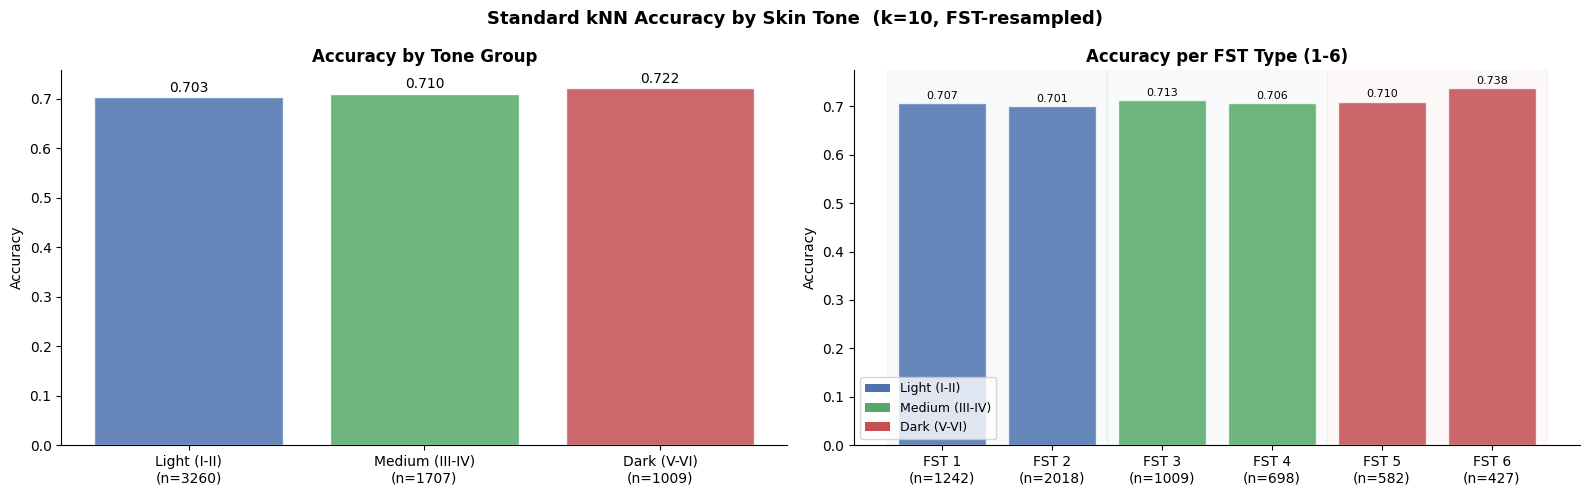

In [16]:
fitz_df   = pred_df[pred_df[FITZ_COL] > 0]
fst_types = sorted(fitz_df[FITZ_COL].unique())

grp_accs = [pred_df[pred_df['tone_group']==g]['correct_standard'].mean() for g in TONE_GROUPS]
grp_ns   = [pred_df[pred_df['tone_group']==g].shape[0]                  for g in TONE_GROUPS]

fst_accs = [fitz_df[fitz_df[FITZ_COL]==t]['correct_standard'].mean() for t in fst_types]
fst_ns   = [fitz_df[fitz_df[FITZ_COL]==t].shape[0]                   for t in fst_types]
fst_colors = [TONE_COLORS[fst_to_tone(t)] for t in fst_types]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: Light / Medium / Dark
ax = axes[0]
x, bar_colors = np.arange(len(TONE_GROUPS)), [TONE_COLORS[g] for g in TONE_GROUPS]
bars = ax.bar(x, grp_accs, color=bar_colors, alpha=0.85, edgecolor='white')
for bar, acc in zip(bars, grp_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f'{g}\n(n={n})' for g, n in zip(TONE_GROUPS, grp_ns)])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy by Tone Group', fontweight='bold')
sns.despine(ax=ax)

# Right: per FST type 1-6
ax = axes[1]
x2 = np.arange(len(fst_types))
bars = ax.bar(x2, fst_accs, color=fst_colors, alpha=0.85, edgecolor='white')
for bar, acc in zip(bars, fst_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=8)
# shade regions
ax.axvspan(-0.5, 1.5, alpha=0.04, color=TONE_COLORS[LIGHT_GROUP])
ax.axvspan(1.5,  3.5, alpha=0.04, color=TONE_COLORS[MEDIUM_GROUP])
ax.axvspan(3.5,  5.5, alpha=0.04, color=TONE_COLORS[DARK_GROUP])
ax.set_xticks(x2)
ax.set_xticklabels([f'FST {t}\n(n={n})' for t, n in zip(fst_types, fst_ns)])
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy per FST Type (1-6)', fontweight='bold')
legend_elements = [Patch(facecolor=TONE_COLORS[g], label=g) for g in TONE_GROUPS]
ax.legend(handles=legend_elements, fontsize=9)
sns.despine(ax=ax)

plt.suptitle(f'Standard kNN Accuracy by Skin Tone  (k={K}, FST-resampled)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/tone_group_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Equity Analysis — Per-Category Accuracy Gaps

In [17]:
label_col = 'nine_partition_label'

equity = (
    pred_df.groupby([label_col, 'tone_group'])
    .agg(acc=('correct_standard','mean'), n=('tone_group','count'))
    .unstack('tone_group')
)
equity.columns = ['_'.join(c).strip() for c in equity.columns]

# Extract per-group accuracy columns
acc_light  = [c for c in equity.columns if 'acc' in c and 'Light'  in c][0]
acc_medium = [c for c in equity.columns if 'acc' in c and 'Medium' in c][0]
acc_dark   = [c for c in equity.columns if 'acc' in c and 'Dark'   in c][0]
n_dark_col = [c for c in equity.columns if 'n_'  in c and 'Dark'   in c][0]

equity = equity.dropna(subset=[acc_light, acc_dark])
equity['gap_dark_light']  = equity[acc_dark]   - equity[acc_light]
equity['gap_dark_medium'] = equity[acc_dark]   - equity[acc_medium]
equity = equity.sort_values('gap_dark_light')

display(equity[[acc_light, acc_medium, acc_dark,
                'gap_dark_light', 'gap_dark_medium', n_dark_col]].round(3))


,acc_Light (I-II),acc_Medium (III-IV),acc_Dark (V-VI),gap_dark_light,gap_dark_medium,n_Dark (V-VI)
nine_partition_label,,,,,,
malignant melanoma,0.436,0.424,0.333,-0.103,-0.090,21
malignant epidermal,0.420,0.337,0.344,-0.076,0.007,32
benign dermal,0.079,0.143,0.062,-0.017,-0.080,48
inflammatory,0.961,0.960,0.957,-0.004,-0.003,702
benign epidermal,0.070,0.129,0.069,-0.001,-0.060,58
malignant cutaneous lymphoma,0.000,0.000,0.000,0.000,0.000,7
malignant dermal,0.000,0.000,0.130,0.130,0.130,23
benign melanocyte,0.022,0.037,0.200,0.178,0.163,15
genodermatoses,0.049,0.160,0.243,0.194,0.083,103


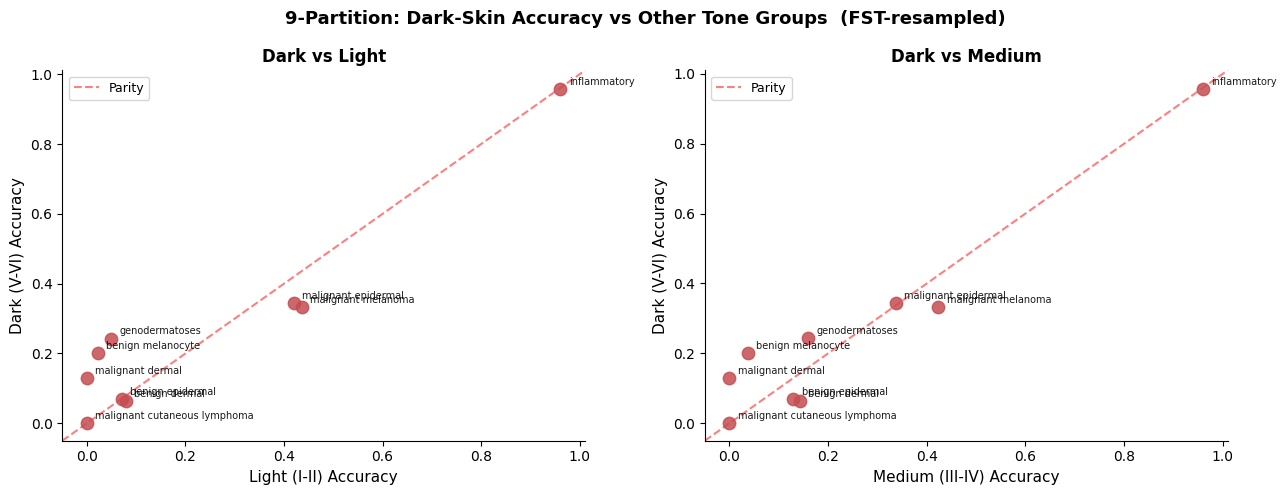

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (col_a, col_b, xlabel, ylabel, title) in zip(axes, [
    (acc_light,  acc_dark,   'Light (I-II) Accuracy',   'Dark (V-VI) Accuracy',   'Dark vs Light'),
    (acc_medium, acc_dark,   'Medium (III-IV) Accuracy', 'Dark (V-VI) Accuracy',  'Dark vs Medium'),
]):
    ax.scatter(equity[col_a], equity[col_b], s=80, alpha=0.85,
               color=TONE_COLORS[DARK_GROUP], zorder=3)
    lims = [min(equity[col_a].min(), equity[col_b].min()) - 0.05,
            max(equity[col_a].max(), equity[col_b].max()) + 0.05]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='Parity')
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(lims); ax.set_ylim(lims)
    for lbl in equity.index:
        ax.annotate(lbl, (equity.loc[lbl, col_a], equity.loc[lbl, col_b]),
                    textcoords='offset points', xytext=(6, 3), fontsize=7, alpha=0.9)
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

plt.suptitle('9-Partition: Dark-Skin Accuracy vs Other Tone Groups  (FST-resampled)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/equity_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Disease Composition by Tone Group

In [19]:
label_col = 'nine_partition_label'

dist = (
    pred_df.groupby(['tone_group', label_col])
    .size()
    .unstack('tone_group')
    .fillna(0)
    .astype(int)
    .reindex(columns=TONE_GROUPS)
)
for grp in TONE_GROUPS:
    dist[f'pct_{grp}'] = dist[grp] / dist[grp].sum()

dist['skew_dark_light'] = dist[f'pct_{DARK_GROUP}'] - dist[f'pct_{LIGHT_GROUP}']
acc = pred_df.groupby(label_col)['correct_standard'].mean().rename('accuracy')
dist = dist.join(acc).sort_values('skew_dark_light', ascending=False)

display(dist[[LIGHT_GROUP, MEDIUM_GROUP, DARK_GROUP,
              f'pct_{LIGHT_GROUP}', f'pct_{MEDIUM_GROUP}', f'pct_{DARK_GROUP}',
              'skew_dark_light', 'accuracy']].round(3))


,Light (I-II),Medium (III-IV),Dark (V-VI),pct_Light (I-II),pct_Medium (III-IV),pct_Dark (V-VI),skew_dark_light,accuracy
nine_partition_label,,,,,,,,
genodermatoses,163,119,103,0.050,0.070,0.102,0.052,0.135
inflammatory,2159,1150,702,0.662,0.674,0.696,0.033,0.960
malignant dermal,18,14,23,0.006,0.008,0.023,0.017,0.055
benign melanocyte,46,27,15,0.014,0.016,0.015,0.001,0.057
benign epidermal,185,116,58,0.057,0.068,0.057,0.001,0.089
malignant cutaneous lymphoma,26,11,7,0.008,0.006,0.007,-0.001,0.000
malignant melanoma,149,59,21,0.046,0.035,0.021,-0.025,0.424
benign dermal,252,119,48,0.077,0.070,0.048,-0.030,0.095
malignant epidermal,262,92,32,0.080,0.054,0.032,-0.049,0.394


## 9. Tone-Aware Retrieval Ablation (RQ2)

Tone-aware kNN boosts same-tone neighbor similarities for Dark (V-VI) queries before
selecting top-k. This section is self-contained — it re-runs CV with tone-aware enabled
and sweeps the boost parameter. All other sections use standard kNN only.

In [20]:
def run_cv_tone_aware(embeddings, df, label_col='nine_partition_label', k=K, boost=TONE_BOOST):
    """CV collecting both standard and tone-aware predictions."""
    labels = df[label_col].values
    tones  = df['tone_group'].values

    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    out_idx, std_all, tone_all = [], [], []

    for fold, (tr_idx, te_idx) in enumerate(skf.split(embeddings, labels)):
        tr_embs, tr_labels, tr_tones = embeddings[tr_idx], labels[tr_idx], tones[tr_idx]
        te_embs, te_labels, te_tones = embeddings[te_idx], labels[te_idx], tones[te_idx]

        sp = knn_predict(te_embs, tr_embs, tr_labels, k=k)
        tp = tone_aware_knn_predict(te_embs, te_tones, tr_embs, tr_labels, tr_tones,
                                    k=k, boost=boost)
        out_idx.extend(te_idx)
        std_all.extend(sp)
        tone_all.extend(tp)
        print(f'  Fold {fold+1}/{N_SPLITS}  std={accuracy_score(te_labels,sp):.3f}  '
              f'tone-aware={accuracy_score(te_labels,tp):.3f}')

    order = np.argsort(out_idx)
    out_df = df.copy()
    out_df['true_label']         = labels
    out_df['pred_standard']      = np.array(std_all)[order]
    out_df['pred_tone_aware']    = np.array(tone_all)[order]
    out_df['correct_standard']   = (out_df['true_label'] == out_df['pred_standard']).astype(int)
    out_df['correct_tone_aware'] = (out_df['true_label'] == out_df['pred_tone_aware']).astype(int)
    return out_df

print(f'Running tone-aware CV (boost={TONE_BOOST})...')
pred_df_ta = run_cv_tone_aware(emb_resampled, df_resampled, k=K, boost=TONE_BOOST)

# Summary: standard vs tone-aware per tone group
print('\n=== Standard vs Tone-Aware Accuracy ===')
rows = []
for grp in ['Overall'] + TONE_GROUPS:
    mask = [True]*len(pred_df_ta) if grp == 'Overall' else pred_df_ta['tone_group']==grp
    std  = pred_df_ta.loc[mask, 'correct_standard'].mean()
    tone = pred_df_ta.loc[mask, 'correct_tone_aware'].mean()
    rows.append({'group': grp, 'standard': round(std,3), 'tone_aware': round(tone,3),
                 'delta': round(tone-std,3)})
display(pd.DataFrame(rows).set_index('group'))


Running tone-aware CV (boost=1.25)...
  Fold 1/5  std=0.695  tone-aware=0.686
  Fold 2/5  std=0.711  tone-aware=0.709
  Fold 3/5  std=0.717  tone-aware=0.710
  Fold 4/5  std=0.710  tone-aware=0.714
  Fold 5/5  std=0.707  tone-aware=0.701

=== Standard vs Tone-Aware Accuracy ===


,standard,tone_aware,delta
group,,,
Overall,0.708,0.704,-0.004
Light (I-II),0.703,0.703,0.000
Medium (III-IV),0.710,0.710,0.000
Dark (V-VI),0.722,0.698,-0.024


Boost sweep...
  boost=1.00 | Light=0.703 | Medium=0.710 | Dark=0.722
  boost=1.10 | Light=0.703 | Medium=0.710 | Dark=0.699
  boost=1.25 | Light=0.703 | Medium=0.710 | Dark=0.698
  boost=1.50 | Light=0.703 | Medium=0.710 | Dark=0.698
  boost=1.75 | Light=0.703 | Medium=0.710 | Dark=0.698
  boost=2.00 | Light=0.703 | Medium=0.710 | Dark=0.698
  boost=2.50 | Light=0.703 | Medium=0.710 | Dark=0.698
  boost=3.00 | Light=0.703 | Medium=0.710 | Dark=0.698


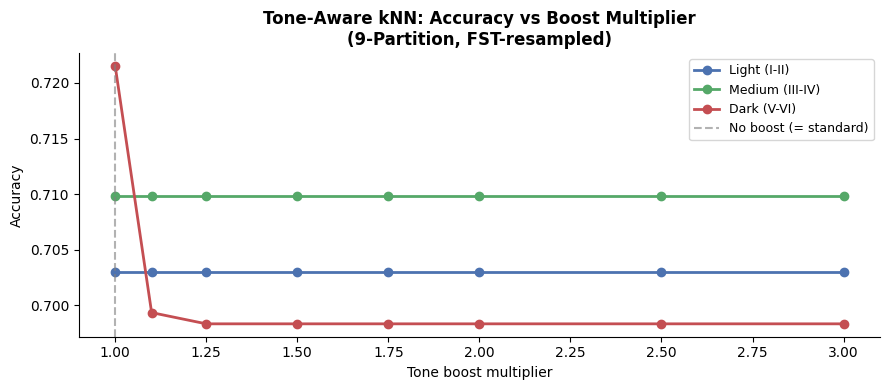

In [21]:
boost_values = [1.0, 1.1, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]
results = defaultdict(list)

label_col = 'nine_partition_label'
labels_cv = df_resampled[label_col].values
tones_cv  = df_resampled['tone_group'].values
skf_cv    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds_cv  = list(skf_cv.split(emb_resampled, labels_cv))

print('Boost sweep...')
for b in boost_values:
    fold_accs = defaultdict(list)
    for tr_idx, te_idx in folds_cv:
        tr_e, tr_l, tr_t = emb_resampled[tr_idx], labels_cv[tr_idx], tones_cv[tr_idx]
        te_e, te_l, te_t = emb_resampled[te_idx], labels_cv[te_idx], tones_cv[te_idx]
        tp = tone_aware_knn_predict(te_e, te_t, tr_e, tr_l, tr_t, k=K, boost=b)
        for grp in TONE_GROUPS:
            m = te_t == grp
            if m.sum() > 0:
                fold_accs[grp].append(accuracy_score(te_l[m], tp[m]))
    for grp in TONE_GROUPS:
        results[grp].append(np.mean(fold_accs[grp]))
    print(f'  boost={b:.2f} | ' +
          ' | '.join(f'{g.split()[0]}={results[g][-1]:.3f}' for g in TONE_GROUPS))

fig, ax = plt.subplots(figsize=(9, 4))
for grp in TONE_GROUPS:
    ax.plot(boost_values, results[grp], marker='o', label=grp,
            color=TONE_COLORS[grp], linewidth=2)
ax.axvline(1.0, linestyle='--', color='gray', alpha=0.6, label='No boost (= standard)')
ax.set_xlabel('Tone boost multiplier')
ax.set_ylabel('Accuracy')
ax.set_title('Tone-Aware kNN: Accuracy vs Boost Multiplier\n(9-Partition, FST-resampled)',
             fontweight='bold')
ax.legend(fontsize=9)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('/content/boost_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. k Sweep (Standard kNN)

k sweep (standard kNN, 9-partition, FST-resampled)...
  k= 1
  k= 3
  k= 5
  k=10
  k=15
  k=20
  k=30


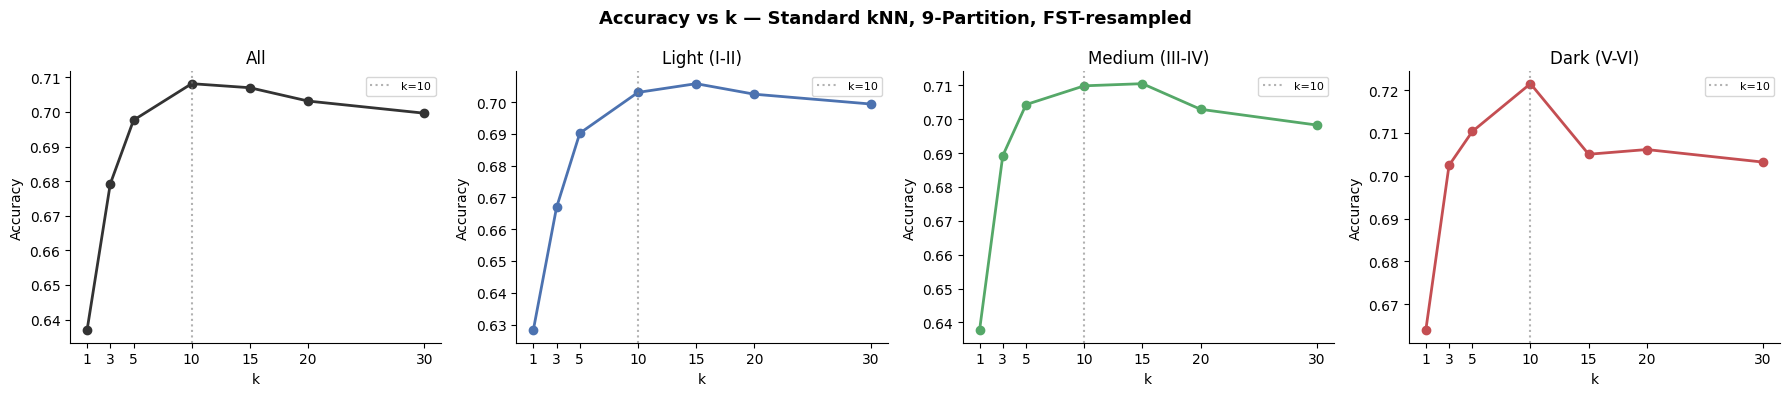

In [22]:
k_values  = [1, 3, 5, 10, 15, 20, 30]
k_results = defaultdict(list)

label_col = 'nine_partition_label'
labels_cv = df_resampled[label_col].values
tones_cv  = df_resampled['tone_group'].values
skf_cv    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
folds_cv  = list(skf_cv.split(emb_resampled, labels_cv))

print('k sweep (standard kNN, 9-partition, FST-resampled)...')
for k in k_values:
    fold_accs = defaultdict(list)
    for tr_idx, te_idx in folds_cv:
        tr_e, tr_l, tr_t = emb_resampled[tr_idx], labels_cv[tr_idx], tones_cv[tr_idx]
        te_e, te_l, te_t = emb_resampled[te_idx], labels_cv[te_idx], tones_cv[te_idx]
        sp = knn_predict(te_e, tr_e, tr_l, k=k)
        fold_accs['all'].append(accuracy_score(te_l, sp))
        for grp in TONE_GROUPS:
            m = te_t == grp
            if m.sum() > 0:
                fold_accs[grp].append(accuracy_score(te_l[m], sp[m]))
    for key in ['all'] + TONE_GROUPS:
        k_results[key].append(np.mean(fold_accs[key]))
    print(f'  k={k:2d}')

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
for ax, grp, title, color in zip(axes,
    ['all'] + TONE_GROUPS,
    ['All'] + TONE_GROUPS,
    ['#333333'] + [TONE_COLORS[g] for g in TONE_GROUPS]
):
    ax.plot(k_values, k_results[grp], marker='o', color=color, linewidth=2)
    ax.axvline(K, linestyle=':', color='gray', alpha=0.6, label=f'k={K}')
    ax.set_xlabel('k'); ax.set_ylabel('Accuracy')
    ax.set_title(title); ax.set_xticks(k_values); ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.suptitle('Accuracy vs k — Standard kNN, 9-Partition, FST-resampled',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/k_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
